### Loan Default Prediction using ML

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Loading the dataset
ldp = pd.read_csv("Loan_default_data.csv")

### LOADING AND UNDERSTANDING DATA

In [3]:
# Basic Data Understanding
print("SHAPE OF DATA:", ldp.shape)
print("\nFIRST FEW ROWS:")
display(ldp.head())
print("\nDATASET INFORMATION:")
ldp.info()
print("\nDESCRIPTIVE STATISTICS OF THE DATASET:")
display(ldp.describe())

SHAPE OF DATA: (257603, 18)

FIRST FEW ROWS:


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56.0,85994.0,50587.0,520.0,80.0,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69.0,50432.0,124440.0,458.0,15.0,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46.0,84208.0,129188.0,451.0,26.0,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32.0,31713.0,44799.0,743.0,0.0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60.0,20437.0,9139.0,633.0,8.0,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0



DATASET INFORMATION:
<class 'pandas.DataFrame'>
RangeIndex: 257603 entries, 0 to 257602
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          257603 non-null  str    
 1   Age             255561 non-null  float64
 2   Income          255557 non-null  float64
 3   LoanAmount      255549 non-null  float64
 4   CreditScore     255697 non-null  float64
 5   MonthsEmployed  255481 non-null  float64
 6   NumCreditLines  257603 non-null  int64  
 7   InterestRate    255731 non-null  float64
 8   LoanTerm        257603 non-null  int64  
 9   DTIRatio        255563 non-null  float64
 10  Education       257603 non-null  str    
 11  EmploymentType  257603 non-null  str    
 12  MaritalStatus   257603 non-null  str    
 13  HasMortgage     257603 non-null  str    
 14  HasDependents   257603 non-null  str    
 15  LoanPurpose     257603 non-null  str    
 16  HasCoSigner     257603 non-null  str    
 17 

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255561.000000,2.555570e+05,2.555490e+05,255697.000000,255481.000000,257603.000000,255731.000000,257603.000000,255563.00000,257603.000000
mean,43.502119,8.472380e+04,1.306194e+05,575.011830,59.553239,2.501066,14.739563,36.022686,0.50022,0.115111
std,14.993387,6.278980e+04,1.022895e+05,167.665449,34.640378,1.117061,24.993709,16.971124,0.23093,0.319157
min,18.000000,-1.499840e+04,-2.499330e+04,1.000000,0.000000,1.000000,-50.000000,12.000000,0.10000,0.000000
25%,31.000000,4.863400e+04,6.574900e+04,436.000000,30.000000,2.000000,7.760000,24.000000,0.30000,0.000000
50%,43.000000,8.246200e+04,1.275040e+05,574.000000,60.000000,2.000000,13.490000,36.000000,0.50000,0.000000
75%,56.000000,1.164330e+05,1.892910e+05,713.000000,90.000000,4.000000,19.320000,48.000000,0.70000,0.000000
max,69.000000,1.498900e+06,2.488630e+06,1500.000000,119.000000,4.000000,500.000000,60.000000,0.90000,1.000000


### DATA CLEANING

In [4]:
# CHECKING FOR DUPLICATE
print("\nNUMBER OF DUPLICATE ROWS IN THE DATASET:", ldp.duplicated().sum())
# VIEWING DUPLICATE ROWS
print("\nDUPLICATE ROWS IN THE DATASET:")
print(ldp[ldp.duplicated()])
#DROPPING DUPLICATE ROWS
print(ldp.drop_duplicates(inplace=True))
print("\nSHAPE OF DATA AFTER DROPPING DUPLICATES:", ldp.shape)


NUMBER OF DUPLICATE ROWS IN THE DATASET: 1935

DUPLICATE ROWS IN THE DATASET:
            LoanID   Age    Income  LoanAmount  CreditScore  MonthsEmployed  \
255348  6QHQ3DY1JW  40.0   24867.0    114210.0        341.0            58.0   
255349  3WU3D6WWCM  45.0   92461.0    209838.0        309.0            79.0   
255350  PLUW4XQ9KG  33.0   54862.0    139152.0        742.0           113.0   
255351  Q7FHSAXAO8  66.0   62385.0    186300.0        688.0            82.0   
255352  EEZ5ZJ8SUT  52.0  147784.0     38490.0        520.0            32.0   
...            ...   ...       ...         ...          ...             ...   
257594  A3DM1I14B3  22.0   88452.0    193666.0          NaN            64.0   
257597  QBGLM7IWT2  21.0       NaN    128956.0        802.0            99.0   
257598  OLGHHGRIWI  28.0   32555.0     13259.0        718.0            44.0   
257599  AI3K3VBW60  43.0   54427.0    109635.0        484.0             0.0   
257600  6A2HAMSVAQ  38.0   62805.0    248384.0      

In [5]:
# MISSING VALUES ANALYSIS
print("Missing Values:")
missing_df = pd.DataFrame({
    'Columns': ldp.columns,
    'Missing_Count': ldp.isnull().sum(),
    'Missing_Percentage': (ldp.isnull().sum() / len(ldp) * 100).round(2)
})
print(missing_df[missing_df['Missing_Count'] > 0])


Missing Values:
                       Columns  Missing_Count  Missing_Percentage
Age                        Age           1968                0.77
Income                  Income           1947                0.76
LoanAmount          LoanAmount           1974                0.77
CreditScore        CreditScore           1817                0.71
MonthsEmployed  MonthsEmployed           2054                0.80
InterestRate      InterestRate           1793                0.70
DTIRatio              DTIRatio           1953                0.76


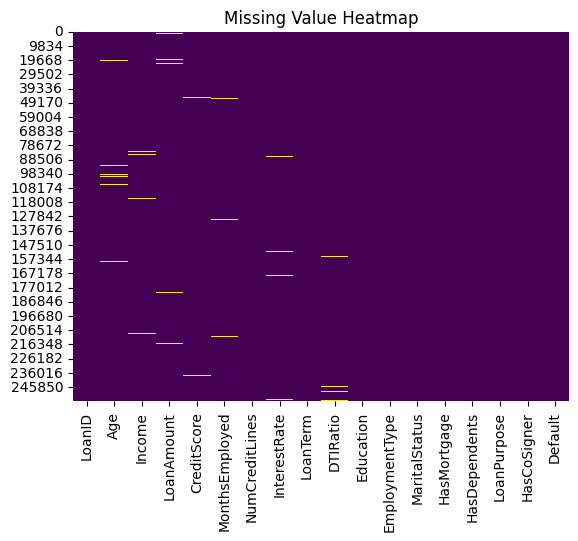

In [6]:
# Visualize missing values
sns.heatmap(ldp.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.show()

In [7]:
# HANDLING MISSING VALUES
# We will drop rows with missing values becouse the percentage of missing values is relatively low and imputation might introduce bias.
ldp.dropna(subset=[
    'Age','Income','LoanAmount','CreditScore','MonthsEmployed','InterestRate','DTIRatio'
    ], inplace=True)

# Dataset shape after handling missing values
print(f"Dataset shape after handling missing values: {ldp.shape}")

Dataset shape after handling missing values: (242162, 18)


In [8]:
# Outlier Detection using IQR
# find outlier count per column
columns_to_check = ['Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio']
for col in columns_to_check:
    Q1 = ldp[col].quantile(0.25)
    Q3 = ldp[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ldp[(ldp[col] < lower) | (ldp[col] > upper)]
    print(f'{col}: {len(outliers)} outliers')

Age: 0 outliers
Income: 610 outliers
LoanAmount: 501 outliers
CreditScore: 1183 outliers
MonthsEmployed: 0 outliers
NumCreditLines: 0 outliers
InterestRate: 1295 outliers
LoanTerm: 0 outliers
DTIRatio: 0 outliers


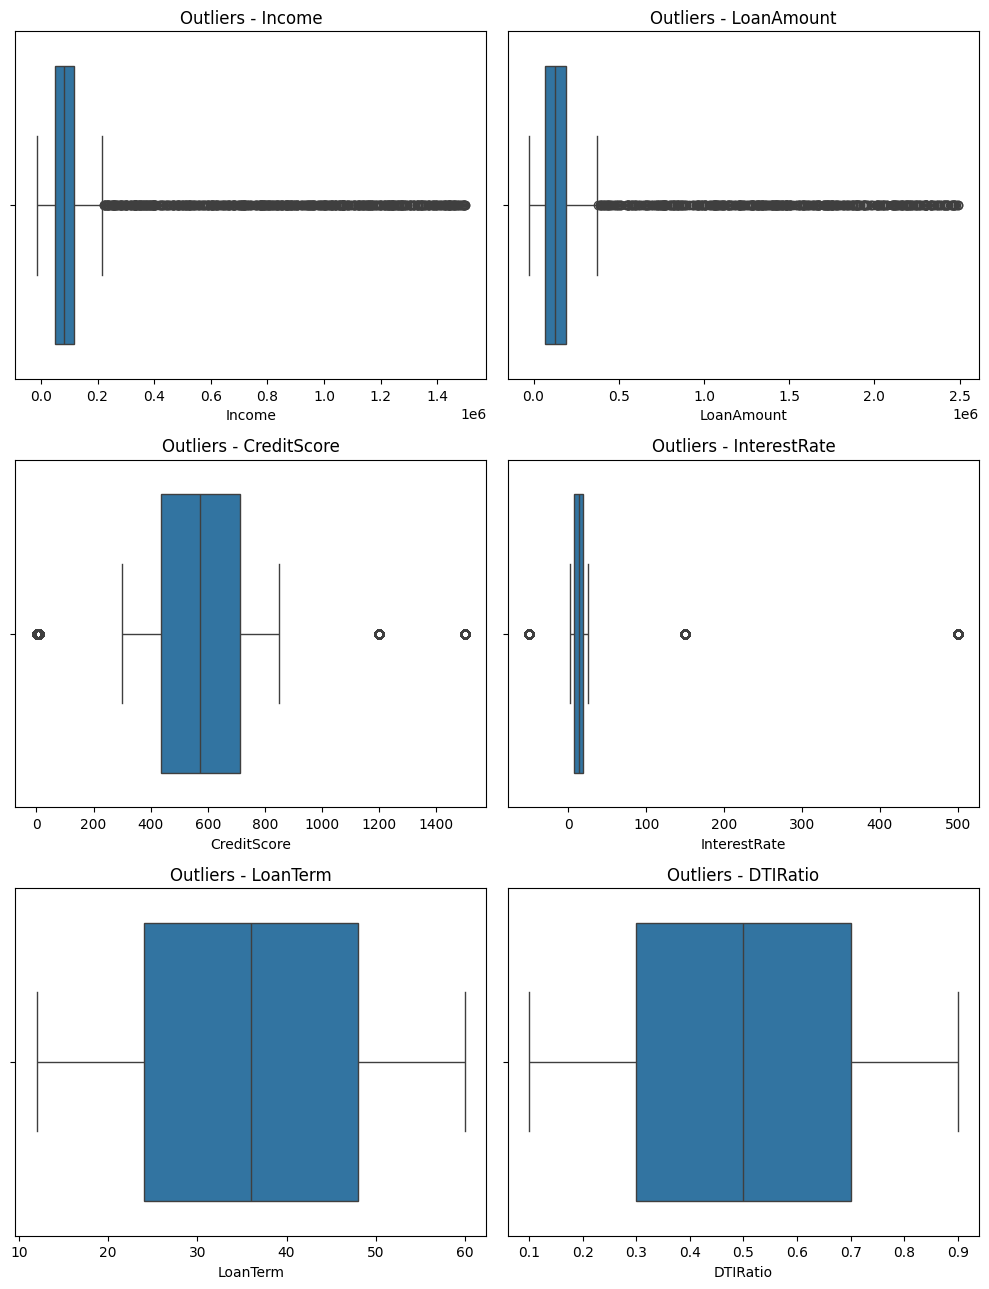

In [9]:
# VISUALIZE OUTLIERS USING BOX PLOTS
cols_has_outlier = ['Income', 'LoanAmount', 'CreditScore',
       'InterestRate', 'LoanTerm','DTIRatio']

fig, axes = plt.subplots(3, 2, figsize=(10,13))
axes = axes.flatten()
for i, col in enumerate(cols_has_outlier):
    sns.boxplot(x=ldp[col], ax=axes[i])
    axes[i].set_title(f'Outliers - {col}')
plt.tight_layout()
plt.show()

In [10]:
# Dropping outliers based on the IQR bounds calculated previously
for col in cols_has_outlier:
    Q1 = ldp[col].quantile(0.25)
    Q3 = ldp[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Keeping only the data within the bounds
    ldp = ldp[(ldp[col] >= lower) & (ldp[col] <= upper)]

print(f"Dataset shape after dropping outliers: {ldp.shape}")

Dataset shape after dropping outliers: (238573, 18)


### UNIVARIATE ANALYSIS

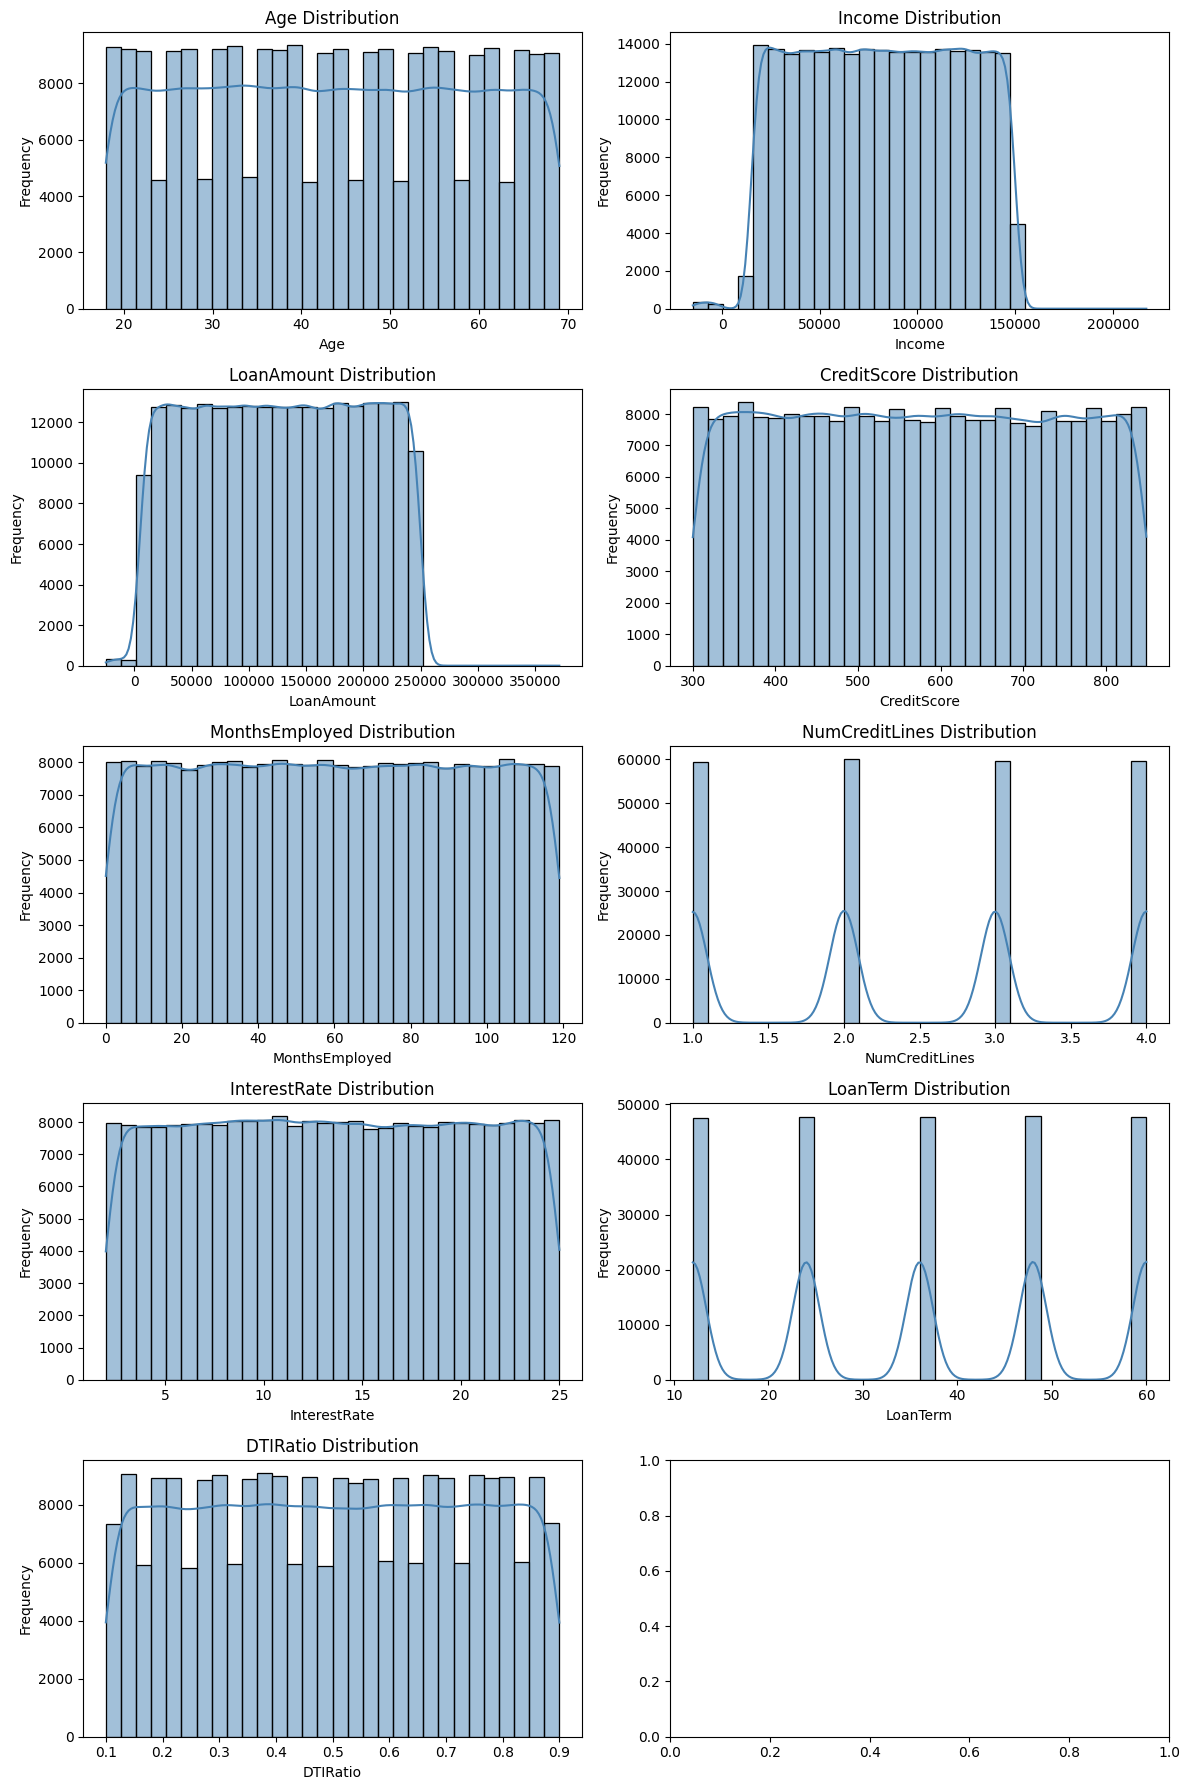


Age
  Mean   : 43.432
  Median : 43.000
  Std    : 15.002
  Skew   : 0.006
  Kurt   : -1.200
-----------------------------------

Income
  Mean   : 82192.120
  Median : 82226.000
  Std    : 39243.921
  Skew   : -0.013
  Kurt   : -1.170
-----------------------------------

LoanAmount
  Mean   : 127398.785
  Median : 127471.000
  Std    : 71126.860
  Skew   : -0.007
  Kurt   : -1.191
-----------------------------------

CreditScore
  Mean   : 573.938
  Median : 573.000
  Std    : 158.920
  Skew   : 0.007
  Kurt   : -1.201
-----------------------------------

MonthsEmployed
  Mean   : 59.447
  Median : 59.000
  Std    : 34.647
  Skew   : 0.001
  Kurt   : -1.200
-----------------------------------

NumCreditLines
  Mean   : 2.501
  Median : 2.000
  Std    : 1.117
  Skew   : 0.000
  Kurt   : -1.358
-----------------------------------

InterestRate
  Mean   : 13.509
  Median : 13.480
  Std    : 6.639
  Skew   : 0.002
  Kurt   : -1.198
-----------------------------------

LoanTerm
  Mean   :

In [11]:
# Numerical Columns Distribution Analysis

numeric_cols = [
    'Age', 'Income', 'LoanAmount', 'CreditScore',
    'MonthsEmployed', 'NumCreditLines',
    'InterestRate', 'LoanTerm', 'DTIRatio'
]

fig, axes = plt.subplots(5, 2, figsize=(12, 18))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    # Histogram with KDE Curve
    sns.histplot(
        ldp[col],
        kde=True,
        bins=30,
        color='steelblue',
        edgecolor='black',
        ax=axes[i],
        line_kws={'color': 'Black'}
    )

    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


# Statistical Summary
for col in numeric_cols:

    print(f"\n{col}")
    print(f"  Mean   : {ldp[col].mean():.3f}")
    print(f"  Median : {ldp[col].median():.3f}")
    print(f"  Std    : {ldp[col].std():.3f}")
    print(f"  Skew   : {ldp[col].skew():.3f}")
    print(f"  Kurt   : {ldp[col].kurt():.3f}")
    print("-" * 35)

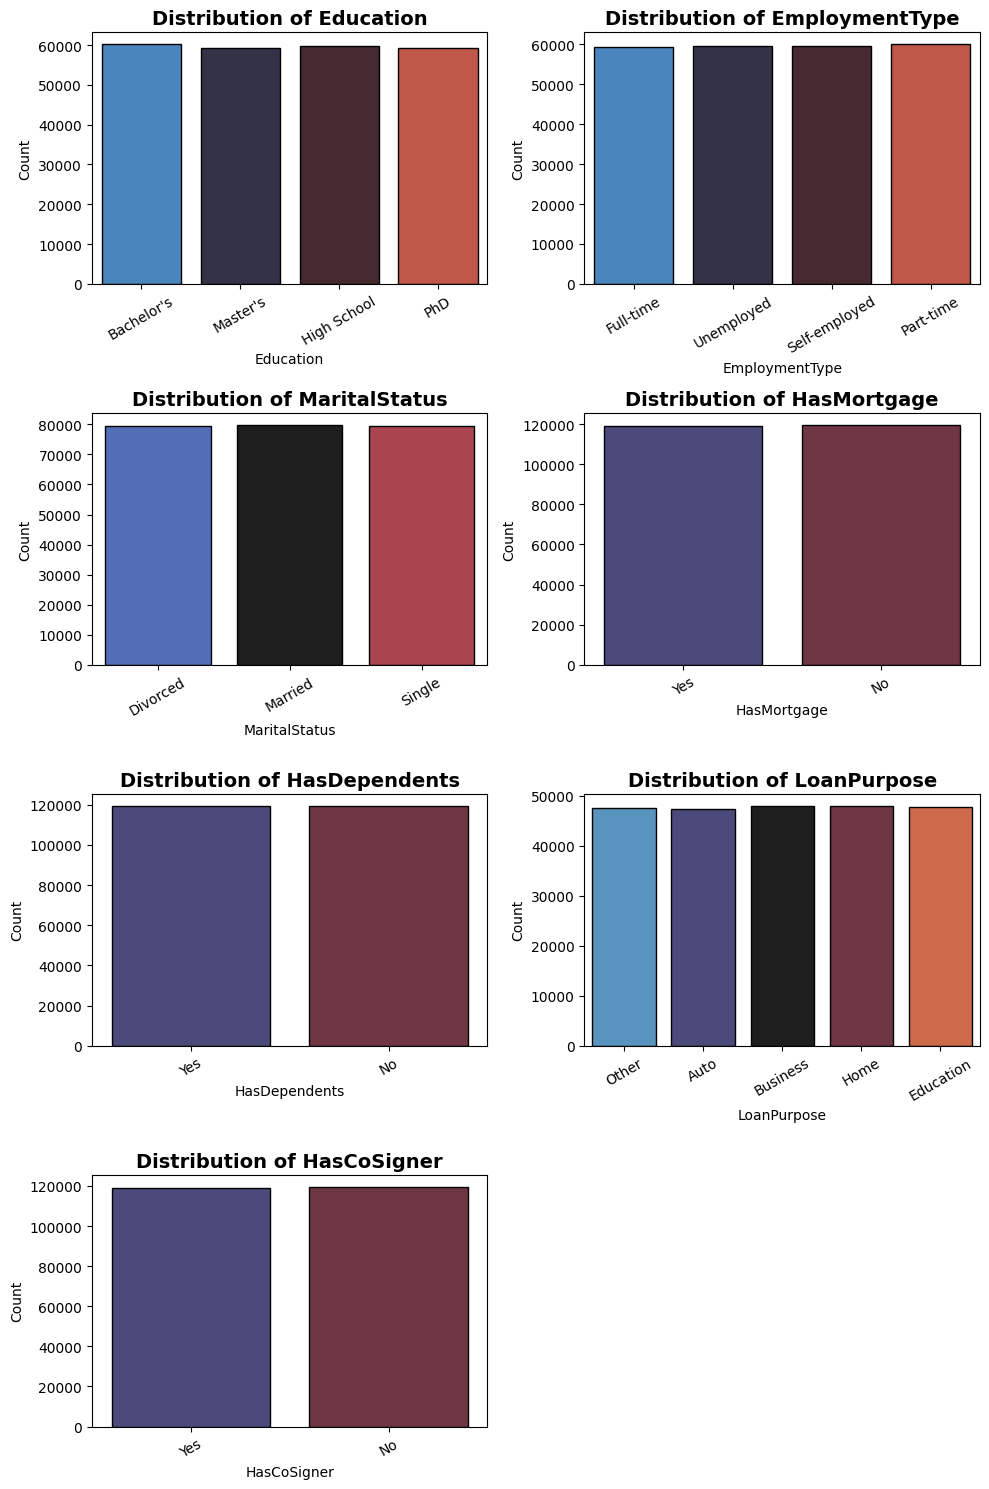


--- Frequency Table for Education ---
Education
Bachelor's     60187
High School    59841
Master's       59292
PhD            59253
Name: count, dtype: int64

--- Frequency Table for EmploymentType ---
EmploymentType
Part-time        60013
Unemployed       59711
Self-employed    59538
Full-time        59311
Name: count, dtype: int64

--- Frequency Table for MaritalStatus ---
MaritalStatus
Married     79729
Divorced    79429
Single      79415
Name: count, dtype: int64

--- Frequency Table for HasMortgage ---
HasMortgage
No     119452
Yes    119121
Name: count, dtype: int64

--- Frequency Table for HasDependents ---
HasDependents
No     119377
Yes    119196
Name: count, dtype: int64

--- Frequency Table for LoanPurpose ---
LoanPurpose
Business     47930
Home         47917
Education    47698
Other        47588
Auto         47440
Name: count, dtype: int64

--- Frequency Table for HasCoSigner ---
HasCoSigner
No     119507
Yes    119066
Name: count, dtype: int64


In [12]:
# Categorical Columns Univariate Analysis
categorical_cols = [
    'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage',
    'HasDependents', 'LoanPurpose', 'HasCoSigner']

fig, axes = plt.subplots(4, 2, figsize=(10, 15))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=ldp, x=col, ax=axes[i], palette= "icefire", edgecolor='black')
    
    # Adding labels and formatting
    axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30) # Rotate for better readability

# Remove the 8th (empty) subplot
fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

# Displaying text-based frequency distribution
for col in categorical_cols:
    print(f"\n--- Frequency Table for {col} ---")
    print(ldp[col].value_counts())

### Bivariate Analysis

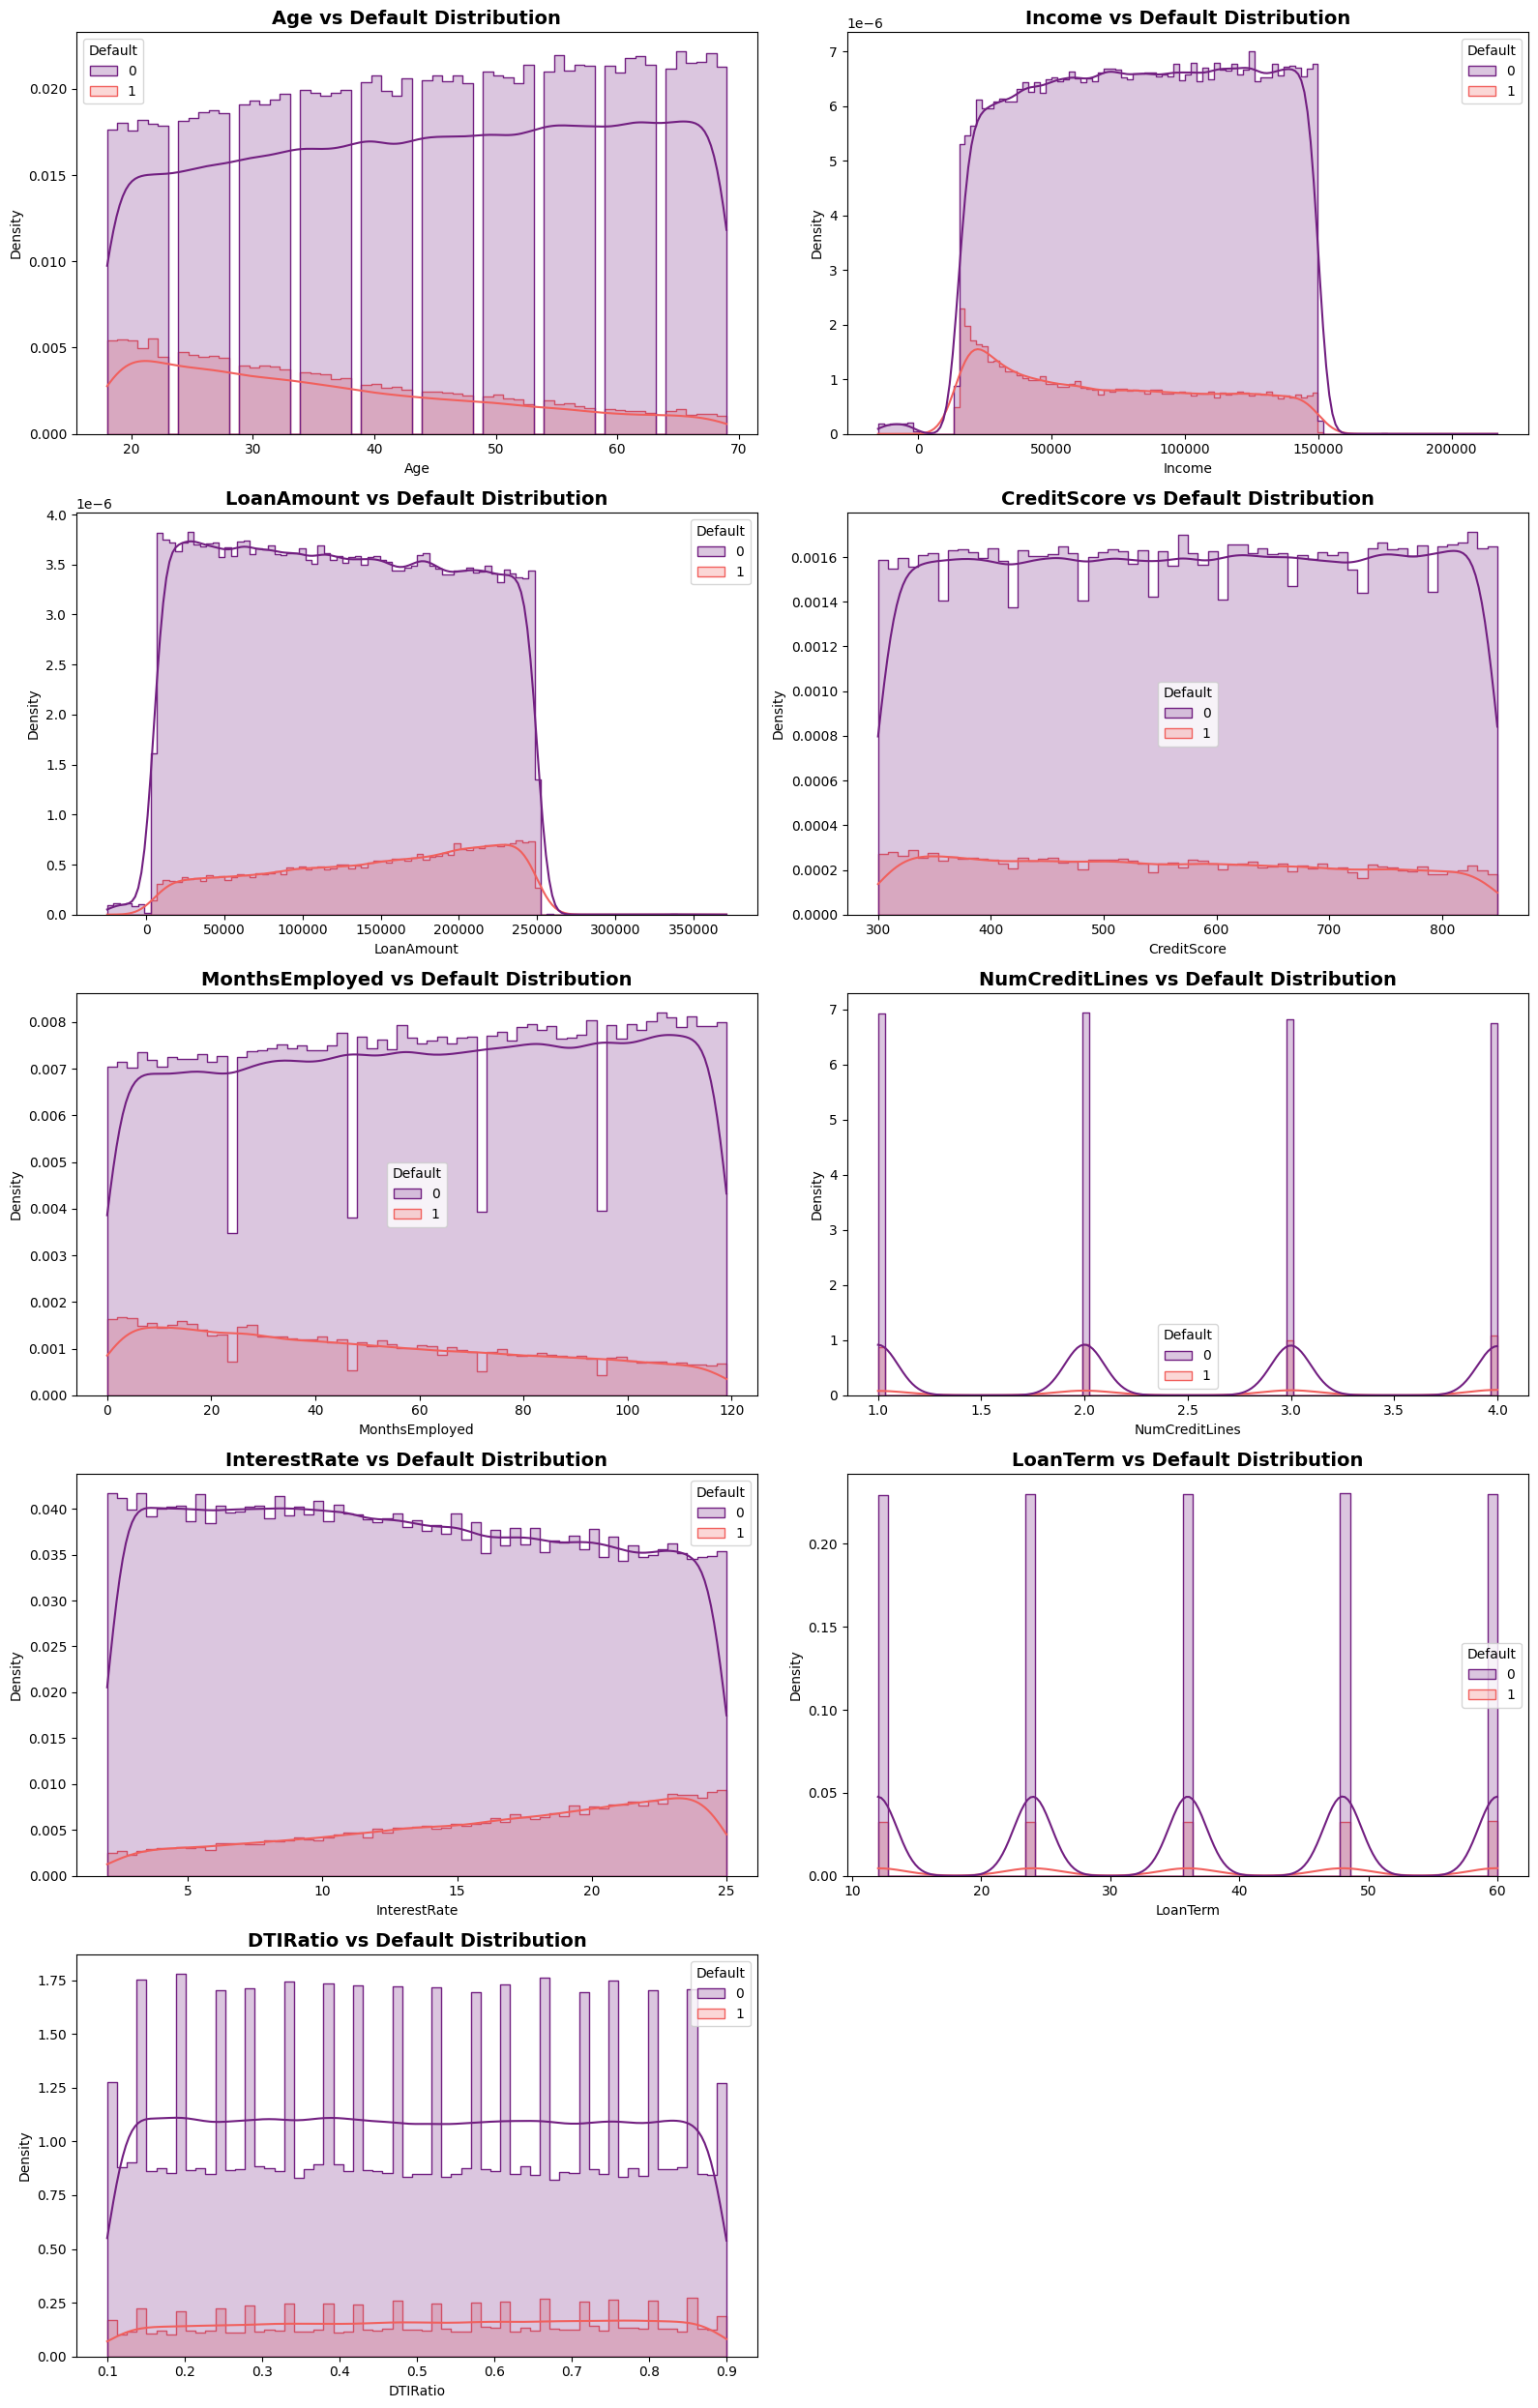

Numerical Correlation with Default:
Default           1.000000
InterestRate      0.135450
LoanAmount        0.090662
NumCreditLines    0.029497
DTIRatio          0.019756
LoanTerm          0.000594
CreditScore      -0.034735
Income           -0.099335
MonthsEmployed   -0.100164
Age              -0.172589
Name: Default, dtype: float64


In [13]:
# Fix: Numerical vs Default Bivariate Analysis (Histplot with KDE)
numeric_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']

# 1. Create a single figure with enough subplots for all columns
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 25))
axes = axes.flatten() # Convert 2D array to 1D for easy looping

for i, col in enumerate(numeric_cols):
    # 2. Use histplot with hue to compare distributions
    # stat='density' allows fair comparison if classes are imbalanced
    sns.histplot(data=ldp, x=col, hue='Default', kde=True, 
                 ax=axes[i], palette='magma', element='step', stat='density')
    
    # 3. Formatting
    axes[i].set_title(f'{col} vs Default Distribution', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

# 4. Remove the empty 10th subplot
fig.delaxes(axes[9])

plt.tight_layout()
plt.show()

# 5. Correlation Check
print("Numerical Correlation with Default:")
print(ldp[numeric_cols + ['Default']].corr()['Default'].sort_values(ascending=False))

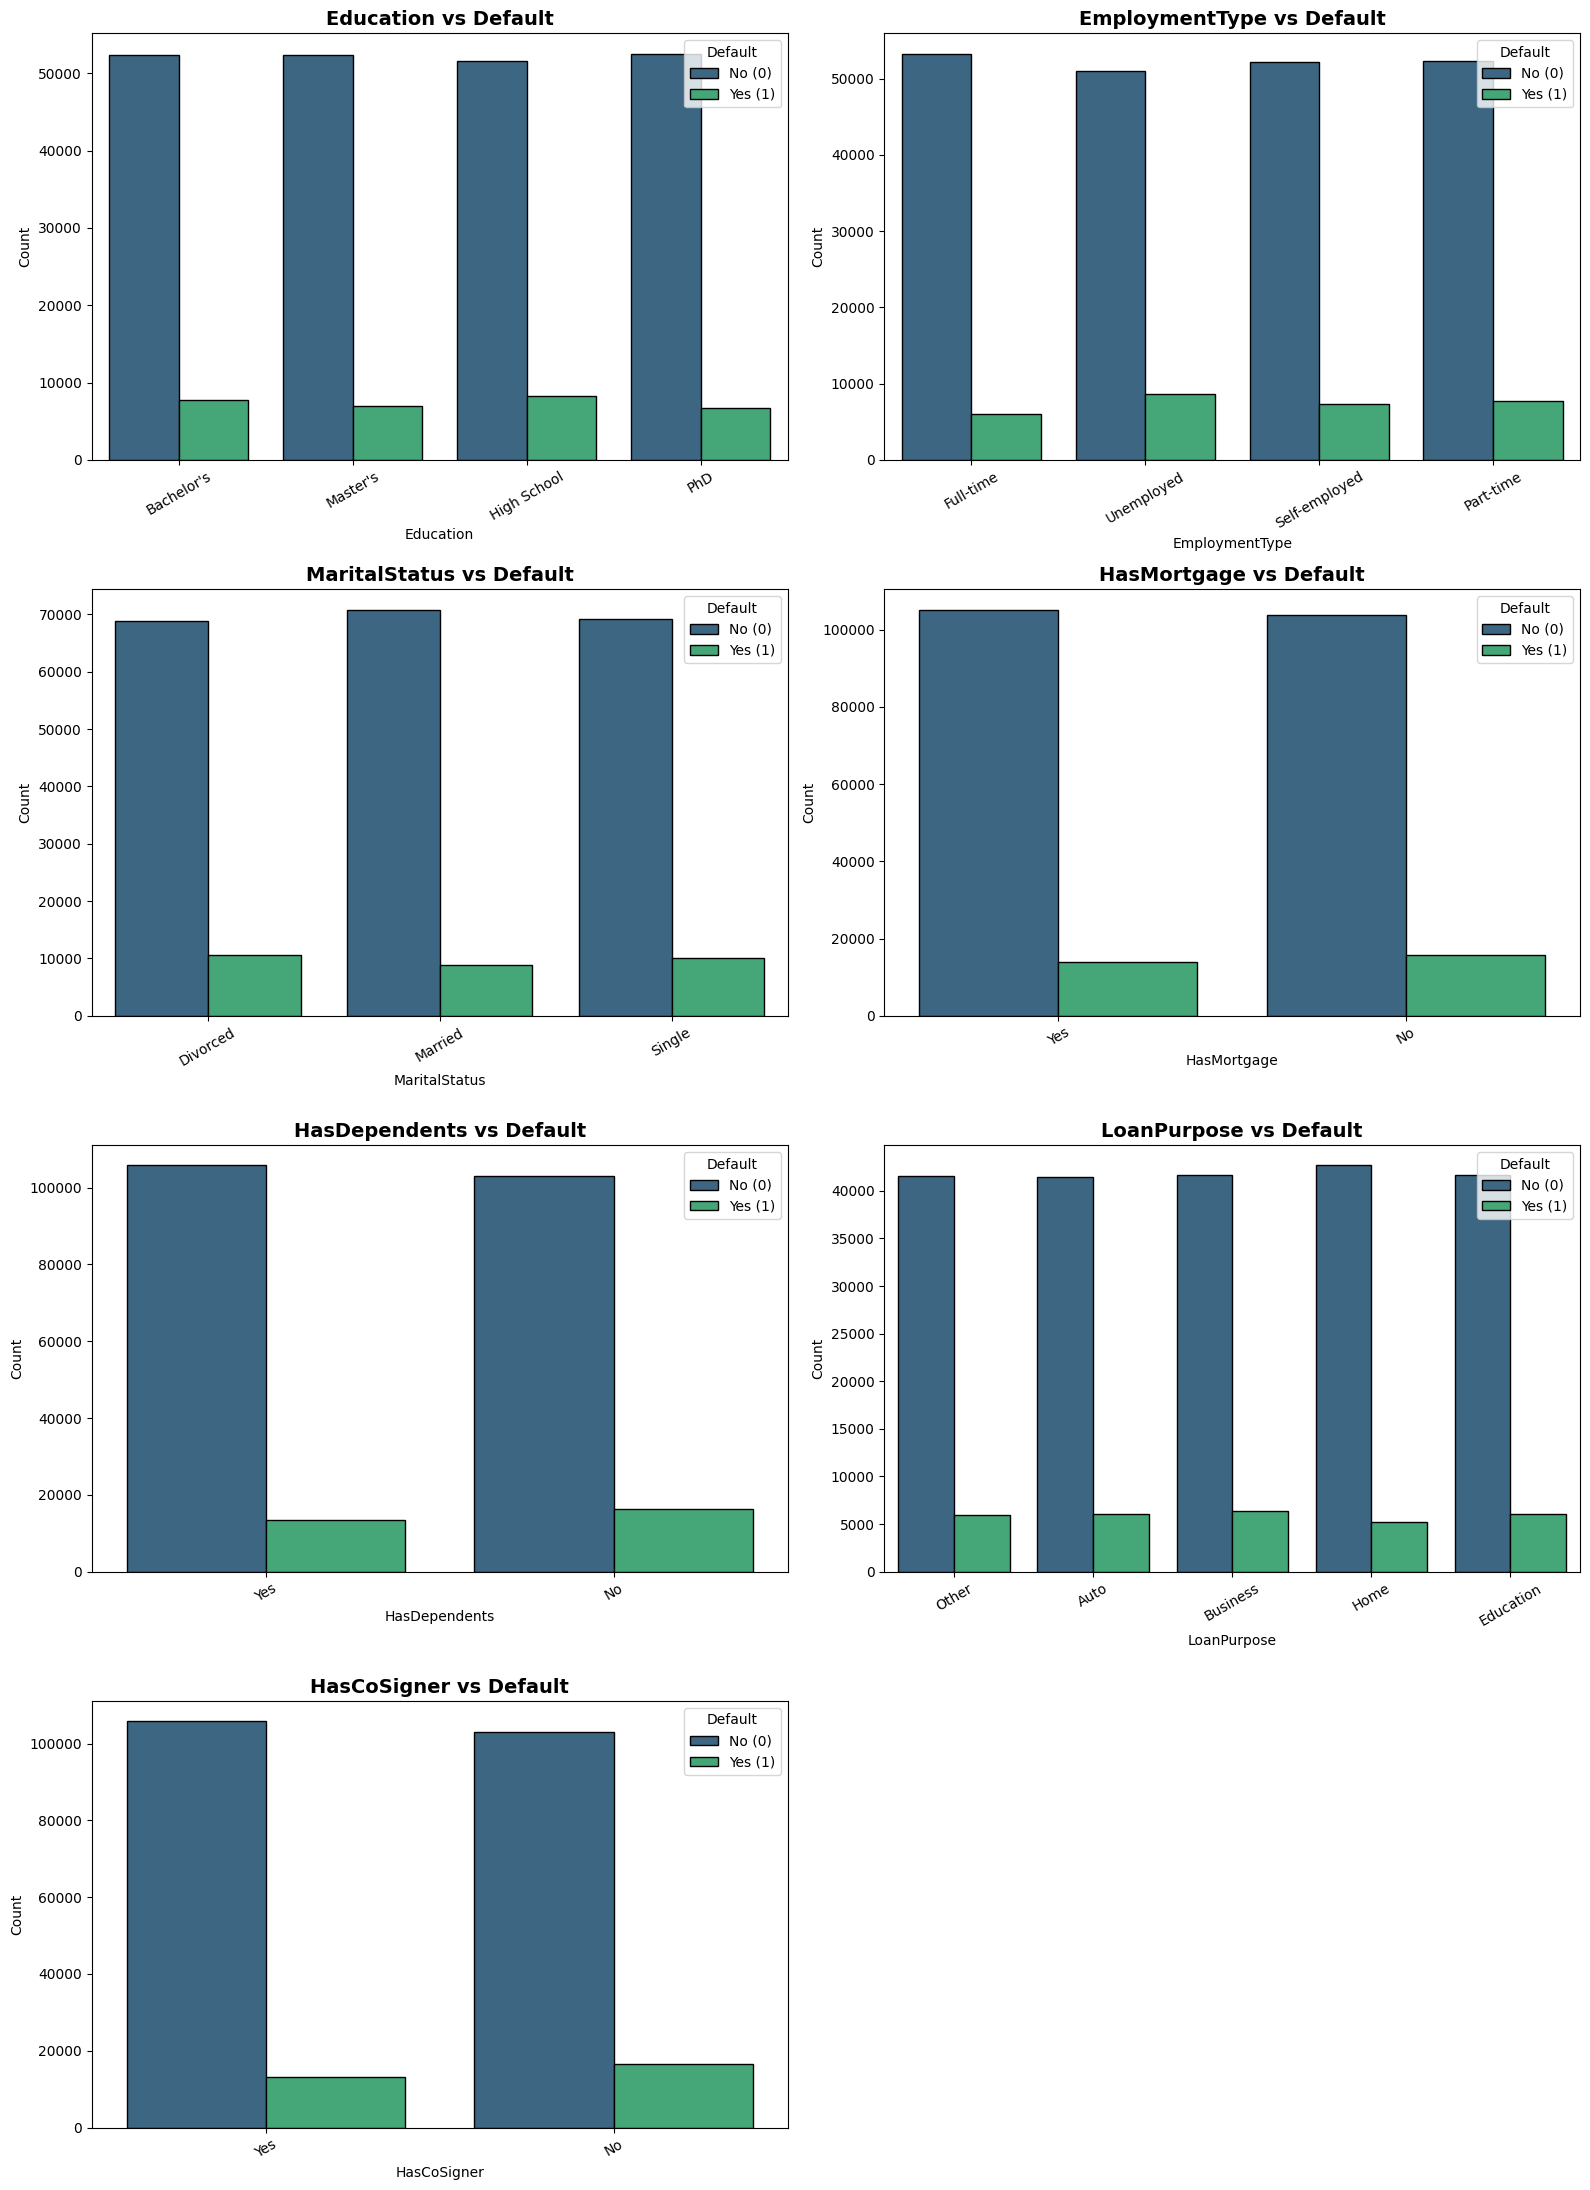

--- Default Rate (%) by Category ---

Education:
Education
High School    13.75
Bachelor's     12.94
Master's       11.65
PhD            11.35
Name: Default, dtype: float64

EmploymentType:
EmploymentType
Unemployed       14.49
Part-time        12.79
Self-employed    12.26
Full-time        10.16
Name: Default, dtype: float64

MaritalStatus:
MaritalStatus
Divorced    13.42
Single      12.75
Married     11.12
Name: Default, dtype: float64

HasMortgage:
HasMortgage
No     13.19
Yes    11.66
Name: Default, dtype: float64

HasDependents:
HasDependents
No     13.60
Yes    11.26
Name: Default, dtype: float64

LoanPurpose:
LoanPurpose
Business     13.19
Auto         12.73
Education    12.66
Other        12.61
Home         10.95
Name: Default, dtype: float64

HasCoSigner:
HasCoSigner
No     13.74
Yes    11.11
Name: Default, dtype: float64


In [14]:
# Categorical Columns vs Default

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Plotting Countplot with 'Default' as the hue to see the split
    sns.countplot(data=ldp, x=col, hue='Default', ax=axes[i], palette='viridis', edgecolor='black')
    
    axes[i].set_title(f'{col} vs Default', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Default', labels=['No (0)', 'Yes (1)'])
    axes[i].tick_params(axis='x', rotation=30)

fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

# Calculating the Default Rate (%) per category for deeper insight
print("--- Default Rate (%) by Category ---")
for col in categorical_cols:
    default_rate = ldp.groupby(col)['Default'].mean() * 100
    print(f"\n{col}:")
    print(default_rate.sort_values(ascending=False).round(2))

### Multivariate Analysis

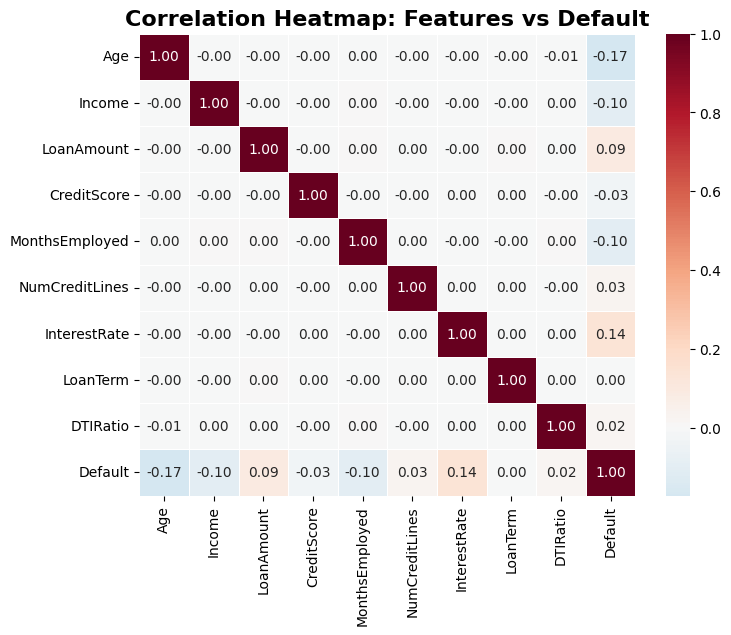

--- Features Ranked by Correlation with Default ---
Default           1.000000
InterestRate      0.135450
LoanAmount        0.090662
NumCreditLines    0.029497
DTIRatio          0.019756
LoanTerm          0.000594
CreditScore      -0.034735
Income           -0.099335
MonthsEmployed   -0.100164
Age              -0.172589
Name: Default, dtype: float64


In [15]:
# Correlation Analysis
plt.figure(figsize=(8, 6))

# 1. Calculate correlation for all numerical columns including the target 'Default'
correlation_matrix = ldp[numeric_cols + ['Default']].corr()

# 2. Plotting the Heatmap
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='RdBu_r',
            center=0, 
            fmt='.2f', 
            linewidths=0.5)

plt.title('Correlation Heatmap: Features vs Default', fontsize=16, fontweight='bold')
plt.show()

# 3. Targeted Correlation: See exactly what affects Default the most
print("--- Features Ranked by Correlation with Default ---")
correlations = ldp[numeric_cols + ['Default']].corr()['Default'].sort_values(ascending=False)
print(correlations)

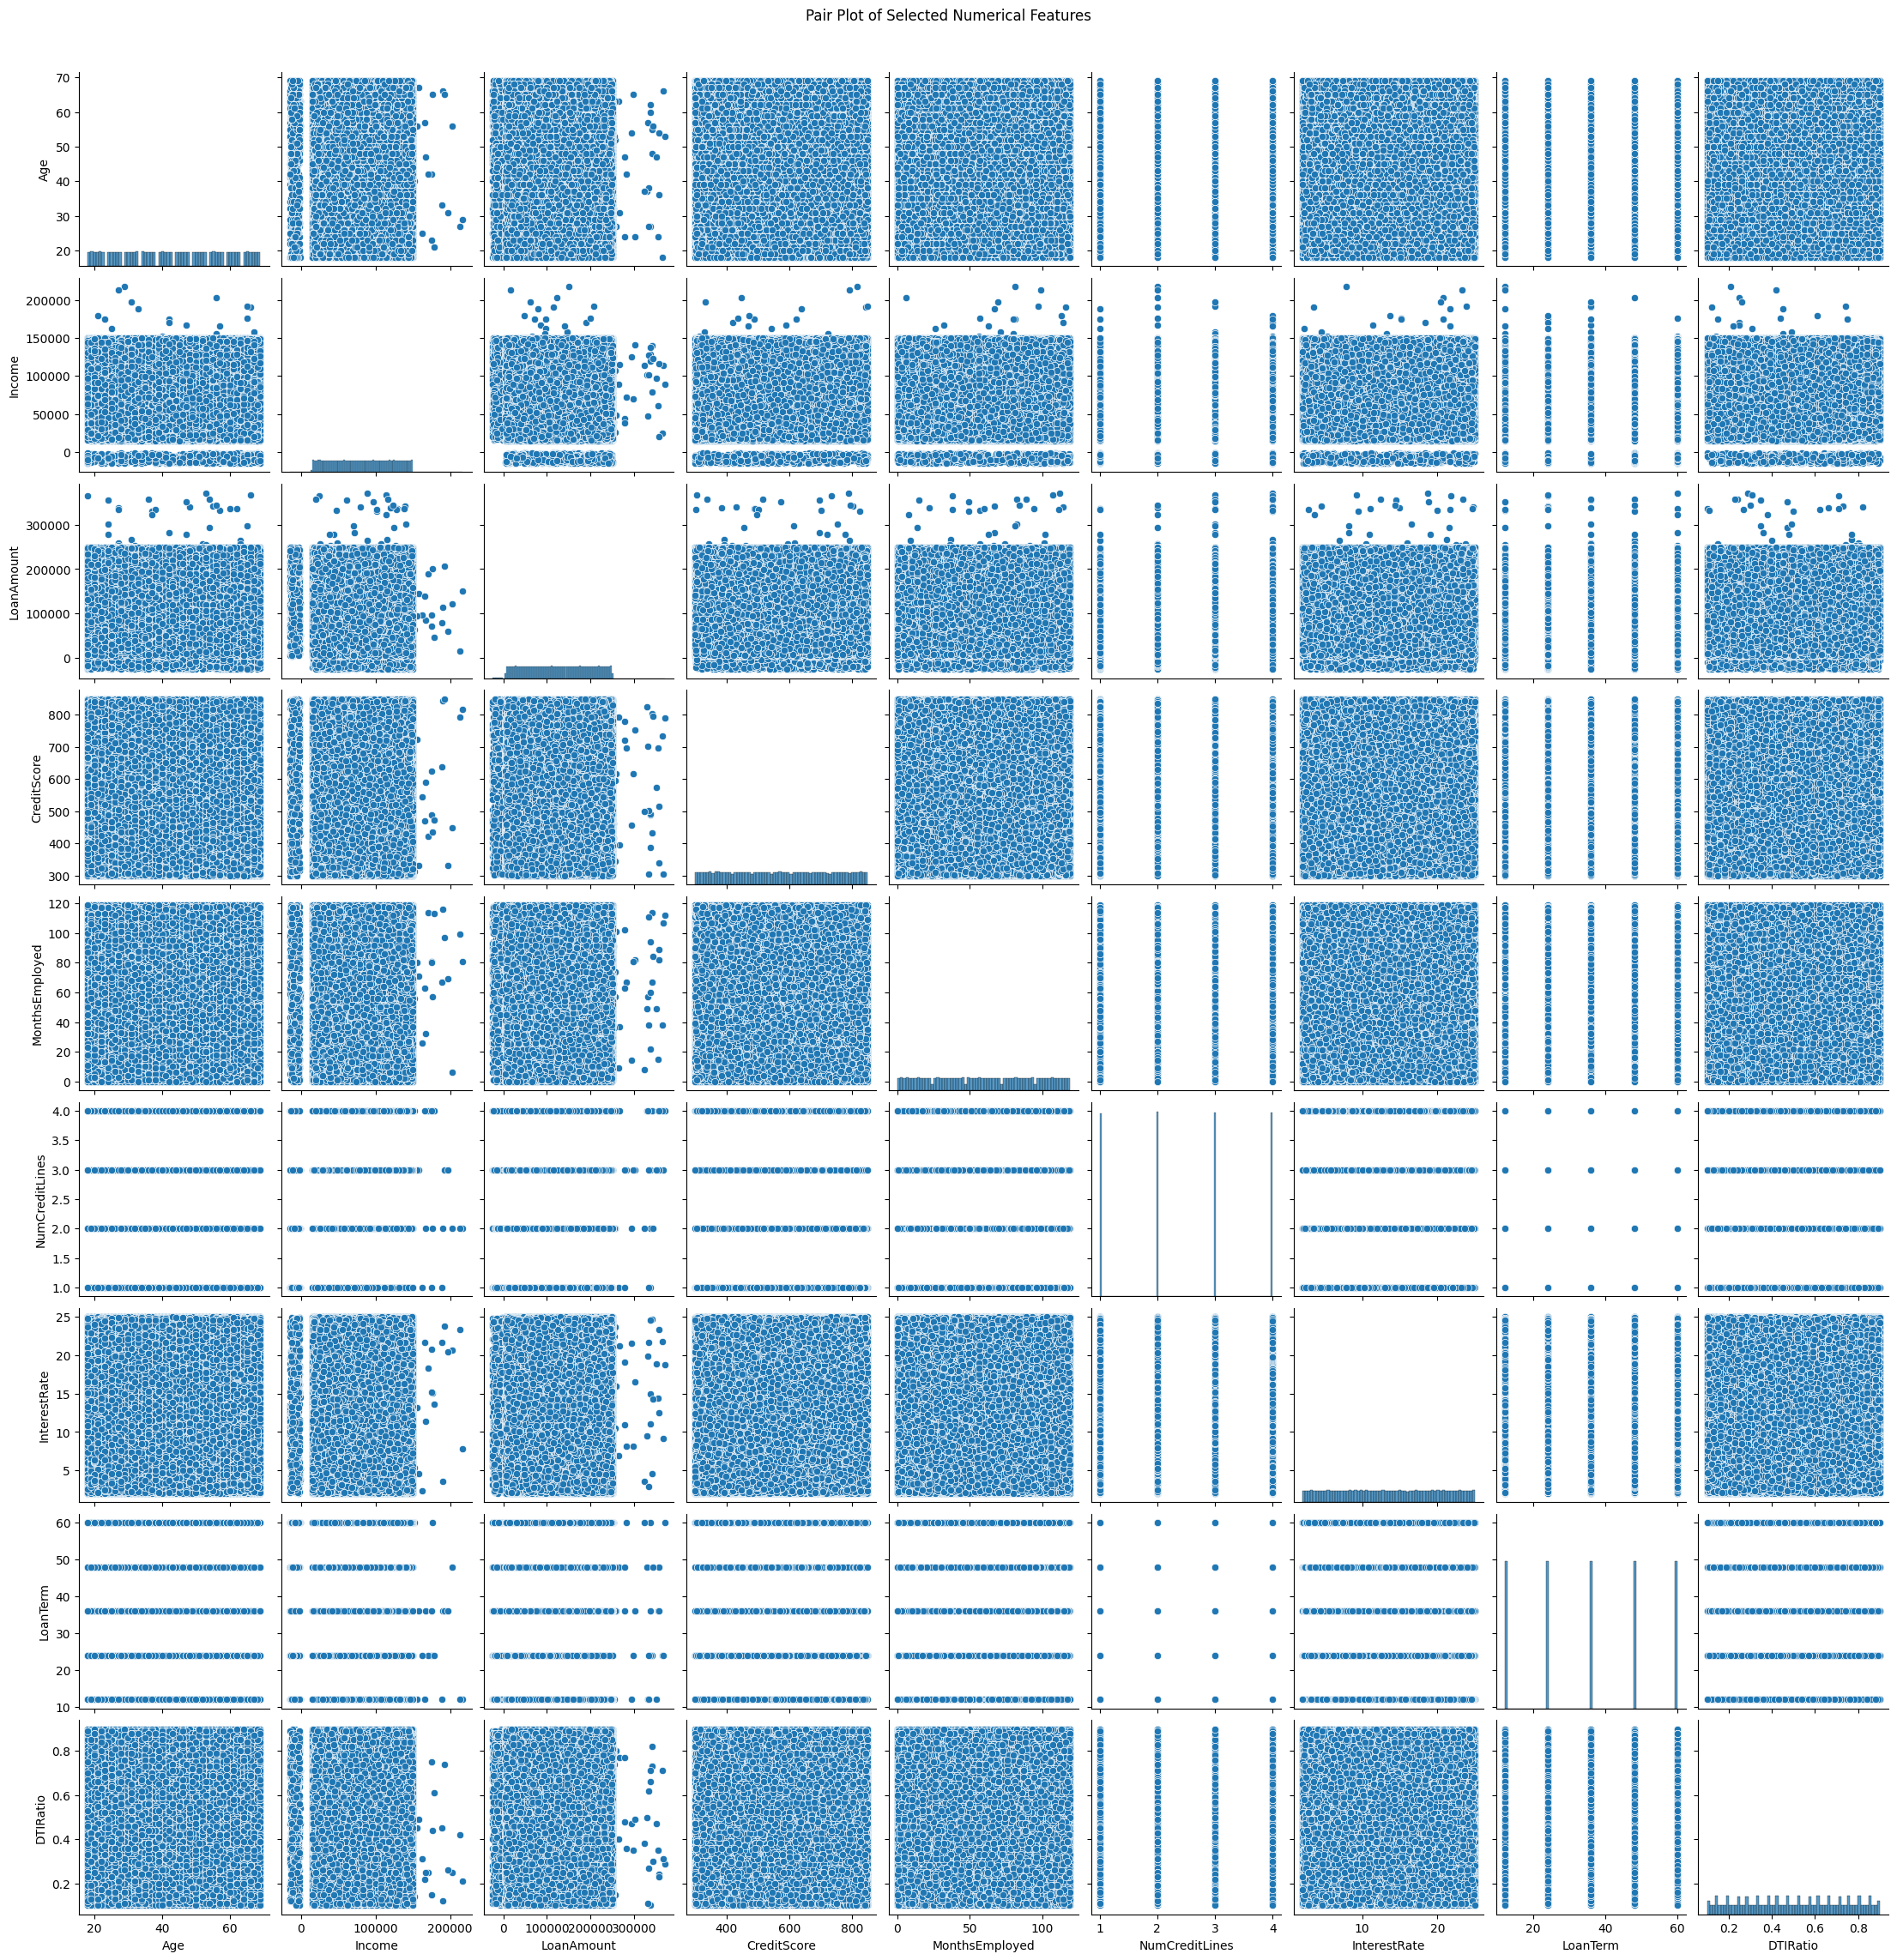

In [16]:
# Pair Plot of Numerical Featurs
sns.pairplot(ldp[numeric_cols])
plt.suptitle('Pair Plot of Selected Numerical Features', y=1.02)
plt.show()

### DATA PREPROCESSING

In [17]:
# Drop LoanID (not useful for modeling)
df = ldp.drop('LoanID', axis=1)

# Separate features and target
X = df.drop('Default', axis=1)
y = df['Default']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"Target distribution (%):\n{y.value_counts(normalize=True) * 100}")

Features shape: (238573, 16)
Target shape: (238573,)

Target distribution:
Default
0    208920
1     29653
Name: count, dtype: int64
Target distribution (%):
Default
0    87.570681
1    12.429319
Name: proportion, dtype: float64


**FEATURE ENGINEERING**

In [18]:
# 1. Create interaction features
X['Income_to_Loan'] = X['Income'] / (X['LoanAmount'] + 1)  # Avoid division by zero
X['Age_Income_Interaction'] = X['Age'] * X['Income']

# 2. Polynomial features for strong predictors
X['Age_squared'] = X['Age'] ** 2
X['CreditScore_squared'] = X['CreditScore'] ** 2

# 3. Binning Age into categories
X['Age_Group'] = pd.cut(X['Age'], bins=[0, 25, 35, 45, 55, 100], 
                         labels=['18-25', '26-35', '36-45', '46-55', '56+'])

# 4. Binning CreditScore
X['CreditScore_Category'] = pd.cut(X['CreditScore'], 
                                    bins=[0, 300, 500, 700, 850, 1500],
                                    labels=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'])

print("Feature Engineering Done!")
print(f"New features shape: {X.shape}")
print(f"\nNew columns:\n{X.columns.tolist()}")

Feature Engineering Done!
New features shape: (238573, 22)

New columns:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Income_to_Loan', 'Age_Income_Interaction', 'Age_squared', 'CreditScore_squared', 'Age_Group', 'CreditScore_Category']


In [19]:
# Importing neccessory ML Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, auc)

**ENCODING**

In [20]:
# Make a copy for encoding
X_encoded = X.copy()

# Identify categorical columns
categorical_cols = X_encoded.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

# One-Hot Encoding for non-ordinal categorical variables
X_encoded = pd.get_dummies(X_encoded, 
                            columns=['Education', 'EmploymentType', 'MaritalStatus', 
                                    'HasMortgage', 'HasDependents', 'LoanPurpose', 
                                    'HasCoSigner', 'Age_Group', 'CreditScore_Category'],
                            drop_first=True)  # Avoid multicollinearity

print(f"\nShape after encoding: {X_encoded.shape}")
print(f"\nEncoded columns:\n{X_encoded.columns.tolist()}")

Categorical columns: ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

Shape after encoding: (238573, 36)

Encoded columns:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Income_to_Loan', 'Age_Income_Interaction', 'Age_squared', 'CreditScore_squared', 'Education_High School', "Education_Master's", 'Education_PhD', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'HasMortgage_Yes', 'HasDependents_Yes', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other', 'HasCoSigner_Yes', 'Age_Group_26-35', 'Age_Group_36-45', 'Age_Group_46-55', 'Age_Group_56+', 'CreditScore_Category_Fair', 'CreditScore_Category_Good', 'CreditScore_Category_Very Good', 'CreditScore_Category_Excellent']


**SCALING**

In [21]:
# Identify numerical columns to scale
numerical_cols = X_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Initialize scaler
scaler = StandardScaler()

# Fit and transform
X_scaled = X_encoded.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

print(f"Scaling Done!")
print(f"\nMean of scaled features (should be ~0):\n{X_scaled[numerical_cols].mean()}")
print(f"\nStd of scaled features (should be ~1):\n{X_scaled[numerical_cols].std()}")

Scaling Done!

Mean of scaled features (should be ~0):
Age                      -2.270658e-16
Income                    1.773877e-16
LoanAmount               -3.404201e-17
CreditScore              -8.541774e-17
MonthsEmployed           -4.634240e-17
NumCreditLines            3.395266e-17
InterestRate             -4.884417e-18
LoanTerm                 -3.627573e-17
DTIRatio                 -2.690003e-16
Income_to_Loan           -7.505324e-18
Age_Income_Interaction    1.866800e-16
Age_squared              -7.886547e-17
CreditScore_squared       5.873214e-17
dtype: float64

Std of scaled features (should be ~1):
Age                       1.000002
Income                    1.000002
LoanAmount                1.000002
CreditScore               1.000002
MonthsEmployed            1.000002
NumCreditLines            1.000002
InterestRate              1.000002
LoanTerm                  1.000002
DTIRatio                  1.000002
Income_to_Loan            1.000002
Age_Income_Interaction    1.00000

### TRAIN TEST SPLIT

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, 
                                                      test_size=0.2, 
                                                      random_state=42,
                                                      stratify=y)  # Keep class balance

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

Training set size: (190858, 36)
Test set size: (47715, 36)

Training target distribution:
Default
0    167136
1     23722
Name: count, dtype: int64

Test target distribution:
Default
0    41784
1     5931
Name: count, dtype: int64


In [23]:
# ============================================================================
# SECTION 6: LOGISTIC REGRESSION
# ============================================================================

print("\n" + "=" * 80)
print("MODEL 1: LOGISTIC REGRESSION")
print("=" * 80)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# Evaluation
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_pred_prob_lr)

print(f"\nLogistic Regression Results:")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")
print(f"AUC-ROC:   {lr_auc:.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_lr)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_lr)}")




MODEL 1: LOGISTIC REGRESSION

Logistic Regression Results:
Accuracy:  0.8776
Precision: 0.6051
Recall:    0.0437
F1-Score:  0.0815
AUC-ROC:   0.7529

Confusion Matrix:
[[41615   169]
 [ 5672   259]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     41784
           1       0.61      0.04      0.08      5931

    accuracy                           0.88     47715
   macro avg       0.74      0.52      0.51     47715
weighted avg       0.85      0.88      0.83     47715



In [24]:
# ============================================================================
# SECTION 7: K-NEAREST NEIGHBORS
# ============================================================================

print("\n" + "=" * 80)
print("MODEL 2: K-NEAREST NEIGHBORS (KNN)")
print("=" * 80)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test)
y_pred_prob_knn = knn_model.predict_proba(X_test)[:, 1]

# Evaluation
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)
knn_auc = roc_auc_score(y_test, y_pred_prob_knn)

print(f"\nKNN Results:")
print(f"Accuracy:  {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall:    {knn_recall:.4f}")
print(f"F1-Score:  {knn_f1:.4f}")
print(f"AUC-ROC:   {knn_auc:.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_knn)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_knn)}")



MODEL 2: K-NEAREST NEIGHBORS (KNN)

KNN Results:
Accuracy:  0.8648
Precision: 0.3409
Recall:    0.0937
F1-Score:  0.1471
AUC-ROC:   0.6282

Confusion Matrix:
[[40709  1075]
 [ 5375   556]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.93     41784
           1       0.34      0.09      0.15      5931

    accuracy                           0.86     47715
   macro avg       0.61      0.53      0.54     47715
weighted avg       0.82      0.86      0.83     47715



In [26]:
# ============================================================================
# SECTION 9: DECISION TREE
# ============================================================================

print("\n" + "=" * 80)
print("MODEL 4: DECISION TREE")
print("=" * 80)

dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)
y_pred_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Evaluation
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_auc = roc_auc_score(y_test, y_pred_prob_dt)

print(f"\nDecision Tree Results:")
print(f"Accuracy:  {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall:    {dt_recall:.4f}")
print(f"F1-Score:  {dt_f1:.4f}")
print(f"AUC-ROC:   {dt_auc:.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_dt)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_dt)}")


MODEL 4: DECISION TREE

Decision Tree Results:
Accuracy:  0.8724
Precision: 0.4151
Recall:    0.0651
F1-Score:  0.1125
AUC-ROC:   0.7199

Confusion Matrix:
[[41240   544]
 [ 5545   386]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     41784
           1       0.42      0.07      0.11      5931

    accuracy                           0.87     47715
   macro avg       0.65      0.53      0.52     47715
weighted avg       0.82      0.87      0.83     47715



In [27]:
# ============================================================================
# SECTION 10: NAIVE BAYES
# ============================================================================

print("\n" + "=" * 80)
print("MODEL 5: NAIVE BAYES")
print("=" * 80)

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test)
y_pred_prob_nb = nb_model.predict_proba(X_test)[:, 1]

# Evaluation
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)
nb_auc = roc_auc_score(y_test, y_pred_prob_nb)

print(f"\nNaive Bayes Results:")
print(f"Accuracy:  {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall:    {nb_recall:.4f}")
print(f"F1-Score:  {nb_f1:.4f}")
print(f"AUC-ROC:   {nb_auc:.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_nb)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_nb)}")



MODEL 5: NAIVE BAYES

Naive Bayes Results:
Accuracy:  0.7477
Precision: 0.2499
Recall:    0.5144
F1-Score:  0.3364
AUC-ROC:   0.7093

Confusion Matrix:
[[32625  9159]
 [ 2880  3051]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.78      0.84     41784
           1       0.25      0.51      0.34      5931

    accuracy                           0.75     47715
   macro avg       0.58      0.65      0.59     47715
weighted avg       0.84      0.75      0.78     47715



In [28]:
# ============================================================================
# SECTION 11: RANDOM FOREST
# ============================================================================

print("\n" + "=" * 80)
print("MODEL 6: RANDOM FOREST")
print("=" * 80)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_pred_prob_rf)

print(f"\nRandom Forest Results:")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")
print(f"AUC-ROC:   {rf_auc:.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_rf)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_rf)}")



MODEL 6: RANDOM FOREST

Random Forest Results:
Accuracy:  0.8775
Precision: 0.5822
Recall:    0.0508
F1-Score:  0.0934
AUC-ROC:   0.7315

Confusion Matrix:
[[41568   216]
 [ 5630   301]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     41784
           1       0.58      0.05      0.09      5931

    accuracy                           0.88     47715
   macro avg       0.73      0.52      0.51     47715
weighted avg       0.84      0.88      0.83     47715




MODEL COMPARISON TABLE


              Model  Accuracy  Precision   Recall  F1-Score  AUC-ROC
Logistic Regression  0.877586   0.605140 0.043669  0.081459 0.752926
                KNN  0.864822   0.340895 0.093745  0.147051 0.628231
      Decision Tree  0.872388   0.415054 0.065082  0.112520 0.719932
        Naive Bayes  0.747689   0.249877 0.514416  0.336365 0.709336
      Random Forest  0.877481   0.582205 0.050750  0.093362 0.731534

--- Best Model for Each Metric ---
Best Accuracy:  Logistic Regression (0.8776)
Best Precision: Logistic Regression (0.6051)
Best Recall:    Naive Bayes (0.5144)
Best F1-Score:  Naive Bayes (0.3364)
Best AUC-ROC:   Logistic Regression (0.7529)


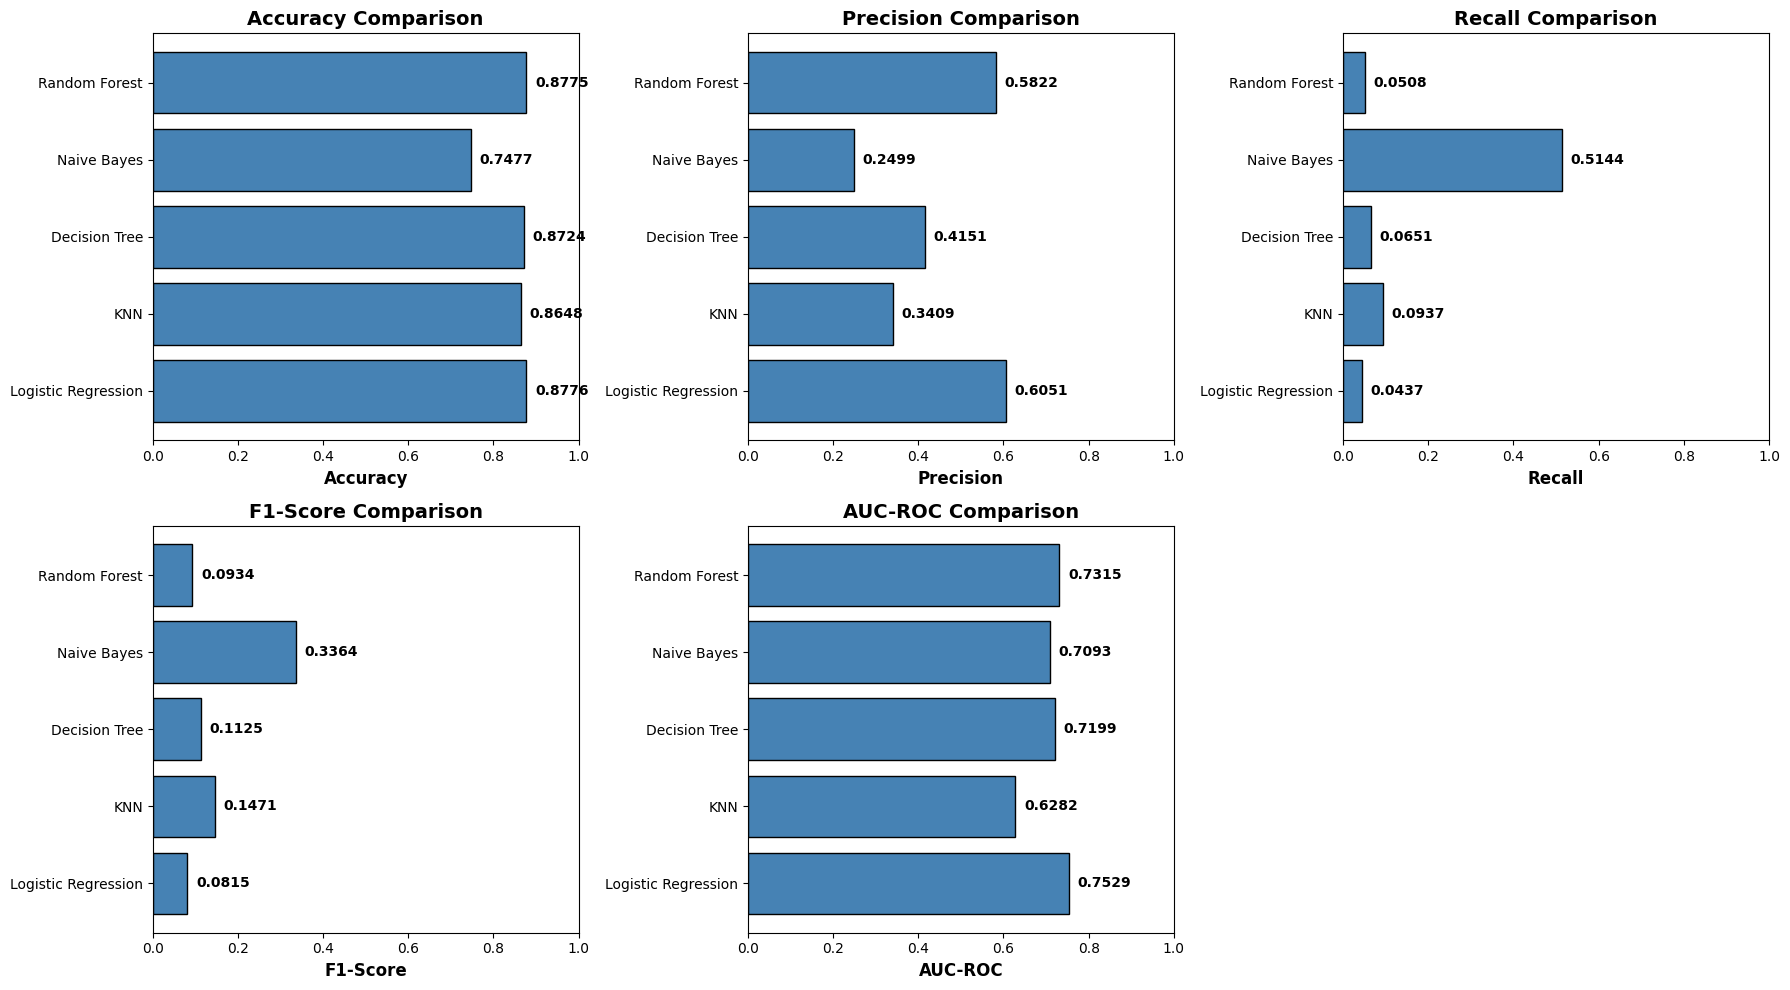

In [35]:
# ============================================================================
# SECTION 12: MODEL COMPARISON
# ============================================================================

print("\n" + "=" * 80)
print("MODEL COMPARISON TABLE")
print("=" * 80)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'Naive Bayes', 'Random Forest'],
    'Accuracy': [lr_accuracy, knn_accuracy, dt_accuracy, nb_accuracy, rf_accuracy],
    'Precision': [lr_precision, knn_precision, dt_precision, nb_precision, rf_precision],
    'Recall': [lr_recall, knn_recall, dt_recall, nb_recall, rf_recall],
    'F1-Score': [lr_f1, knn_f1, dt_f1, nb_f1, rf_f1],
    'AUC-ROC': [lr_auc, knn_auc, dt_auc, nb_auc, rf_auc]
})

print("\n")
print(comparison_df.to_string(index=False))

# Best models for each metric
print("\n--- Best Model for Each Metric ---")
print(f"Best Accuracy:  {comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']} ({comparison_df['Accuracy'].max():.4f})")
print(f"Best Precision: {comparison_df.loc[comparison_df['Precision'].idxmax(), 'Model']} ({comparison_df['Precision'].max():.4f})")
print(f"Best Recall:    {comparison_df.loc[comparison_df['Recall'].idxmax(), 'Model']} ({comparison_df['Recall'].max():.4f})")
print(f"Best F1-Score:  {comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']} ({comparison_df['F1-Score'].max():.4f})")
print(f"Best AUC-ROC:   {comparison_df.loc[comparison_df['AUC-ROC'].idxmax(), 'Model']} ({comparison_df['AUC-ROC'].max():.4f})")

# Visualize comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
for i, metric in enumerate(metrics):
    axes[i].barh(comparison_df['Model'], comparison_df[metric], color='steelblue', edgecolor='black')
    axes[i].set_xlabel(metric, fontsize=12, fontweight='bold')
    axes[i].set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    axes[i].set_xlim([0, 1])
    for j, v in enumerate(comparison_df[metric]):
        axes[i].text(v + 0.02, j, f'{v:.4f}', va='center', fontweight='bold')

# Remove the 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()


ROC CURVES COMPARISON


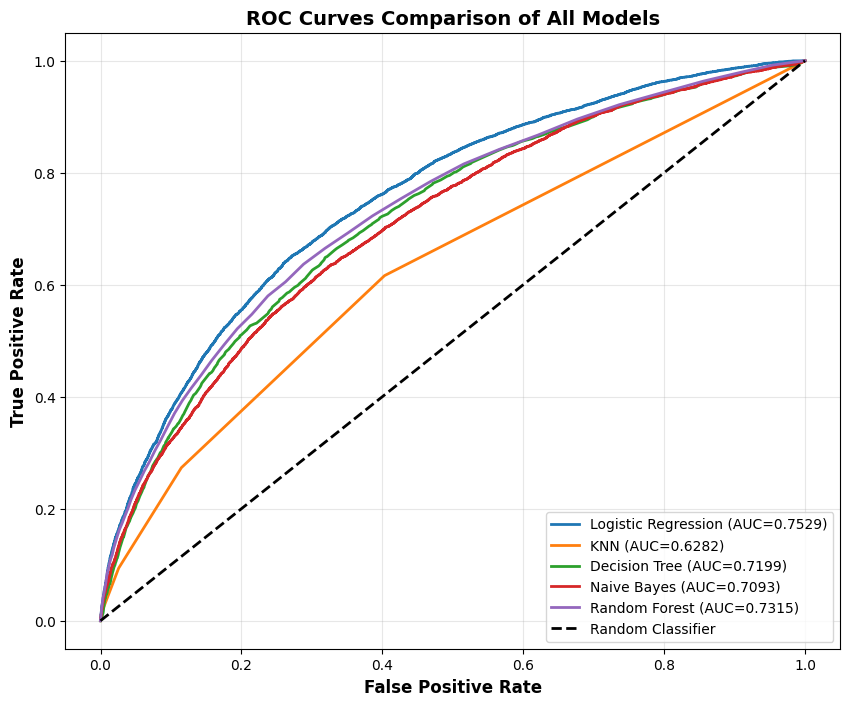


PROJECT COMPLETE


In [36]:
# ============================================================================
# ROC CURVES COMPARISON
# ============================================================================

print("\n" + "=" * 80)
print("ROC CURVES COMPARISON")
print("=" * 80)

plt.figure(figsize=(10, 8))

# Plot ROC curves for all models
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_prob_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_prob_knn)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_prob_dt)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_pred_prob_nb)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={lr_auc:.4f})', linewidth=2)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC={knn_auc:.4f})', linewidth=2)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={dt_auc:.4f})', linewidth=2)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC={nb_auc:.4f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={rf_auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves Comparison of All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "=" * 80)
print("PROJECT COMPLETE")
print("=" * 80)